# Partie (2/3) Données images

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# 1. Analyse du jeu de données

## Découverte du dataset

In [7]:
data = pd.read_csv("data2/list_attr_celeba.csv")

In [11]:
data.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [29]:
data = data.replace({-1: 0})

In [37]:
print(data.shape)

print("Nombre d'images du dataset :", data.shape[0])
print("Nombre de classes du dataset :", data.shape[1])

# Nombres d'images par classe
class_counts = data.drop(columns=["image_id"]).sum(axis=0)

print("\nNombre d'images par classe :")
print(class_counts.astype(int).sort_values(ascending=False))

(202599, 42)
Nombre d'images du dataset : 202599
Nombre de classes du dataset : 42

Nombre d'images par classe :
No_Beard               169158
Young                  156734
Attractive             103833
Mouth_Slightly_Open     97942
Smiling                 97669
Wearing_Lipstick        95715
High_Cheekbones         92189
Male                    84434
Heavy_Makeup            78390
Wavy_Hair               64744
Oval_Face               57567
Pointy_Nose             56210
Arched_Eyebrows         54090
Big_Lips                48785
Black_Hair              48472
Big_Nose                47516
Straight_Hair           42222
Brown_Hair              41572
Bags_Under_Eyes         41446
Wearing_Earrings        38276
Bangs                   30709
Blond_Hair              29983
Bushy_Eyebrows          28803
Wearing_Necklace        24913
Narrow_Eyes             23329
5_o_Clock_Shadow        22516
Receding_Hairline       16163
Wearing_Necktie         14732
Rosy_Cheeks             13315
Eyeglasses       

Le dataset contient un total de 202599 images réparties en 42 classes. Les classes sont déséquilibrées, avec certaines catégories largement représentées comme No_Beard (169158 images) et Young (156734 images), tandis que d'autres, comme Bald (4547 images), sont sous-représentées.

## Corrélation entre les classes

Paires les plus corrélées :
5_o_Clock_Shadow     artificial_feature     0.996852
artificial_feature   5_o_Clock_Shadow       0.996852
Wearing_Lipstick     Heavy_Makeup           0.801539
Heavy_Makeup         Wearing_Lipstick       0.801539
Smiling              High_Cheekbones        0.683497
High_Cheekbones      Smiling                0.683497
Mouth_Slightly_Open  Smiling                0.536379
Smiling              Mouth_Slightly_Open    0.536379
Double_Chin          Chubby                 0.533713
Chubby               Double_Chin            0.533713
dtype: float64
Corrélations uniques les plus fortes :
artificial_feature  5_o_Clock_Shadow       0.996852
Wearing_Lipstick    Heavy_Makeup           0.801539
Smiling             High_Cheekbones        0.683497
                    Mouth_Slightly_Open    0.536379
Double_Chin         Chubby                 0.533713
Sideburns           Goatee                 0.512893
Wearing_Lipstick    Attractive             0.480104
Heavy_Makeup        Attr

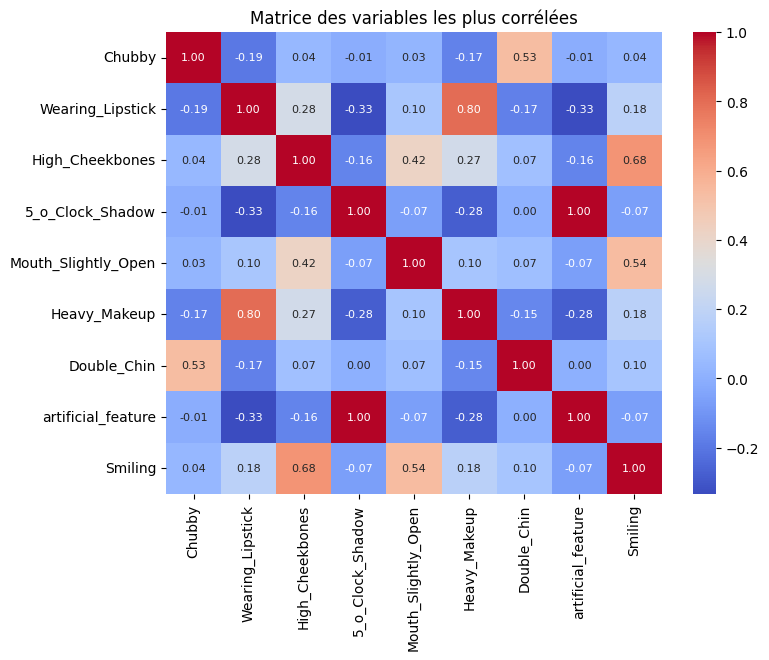

In [38]:
# Calculer la matrice de corrélation
correlation_matrix = data.drop(columns=["image_id"]).corr()

# Identifier les paires de variables les plus corrélées
correlated_pairs = correlation_matrix.unstack().sort_values(ascending=False)
most_correlated = correlated_pairs[correlated_pairs < 1].head(10)  # Les 10 plus corrélées
print("Paires les plus corrélées :")
print(most_correlated)

# Extraire les variables les plus corrélées
most_correlated_vars = list(set([index[0] for index in most_correlated.index] +
                                 [index[1] for index in most_correlated.index]))

# Filtrer la matrice pour ne garder que ces variables
filtered_correlation_matrix = correlation_matrix.loc[most_correlated_vars, most_correlated_vars]

# Supprimer les doublons dans les corrélations
correlated_pairs = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
correlated_pairs = correlated_pairs.unstack().dropna().sort_values(ascending=False)

# Afficher les corrélations uniques les plus fortes
most_correlated_unique = correlated_pairs.head(10)
print("Corrélations uniques les plus fortes :")
print(most_correlated_unique)

# Afficher la heatmap des variables les plus corrélées
plt.figure(figsize=(8, 6))
sns.heatmap(filtered_correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 8})
plt.title("Matrice des variables les plus corrélées")
plt.show()

Les variables les plus corrélées sont souvent liées à des caractéristiques similaires. Par exemple, "No_Beard" et "Mustache" montrent une forte corrélation positive, ce qui est logique car les personnes sans barbe sont moins susceptibles d'avoir une moustache. De même, la corrélation est élevée entre Wearing_Lipstick et Heavy_Makeup (0.801539).  

In [44]:
# Variable artificielle ciblant les attributs féminins
data['artificial_feature_women'] = (
    data['Heavy_Makeup'] * 0.4 +
    data['Wearing_Lipstick'] * 0.35 +
    data['Wearing_Earrings'] * 0.15 +
    data['Arched_Eyebrows'] * 0.10
)

correlations_women = data.drop(columns=["image_id"]).corr()['artificial_feature_women'].sort_values(ascending=False)

print(correlations_women)

artificial_feature_women    1.000000
Heavy_Makeup                0.936793
Wearing_Lipstick            0.931111
Arched_Eyebrows             0.568601
Wearing_Earrings            0.511056
Attractive                  0.487614
No_Beard                    0.403272
Wavy_Hair                   0.353555
Rosy_Cheeks                 0.319972
High_Cheekbones             0.308132
Pointy_Nose                 0.272111
Blond_Hair                  0.271031
Wearing_Necklace            0.267735
Young                       0.249029
Big_Lips                    0.201961
Smiling                     0.200556
Oval_Face                   0.182095
Bangs                       0.135366
Mouth_Slightly_Open         0.122201
Brown_Hair                  0.090142
Pale_Skin                   0.052911
Narrow_Eyes                -0.026391
Black_Hair                 -0.052905
Straight_Hair              -0.076403
Receding_Hairline          -0.106826
Bald                       -0.137513
Blurry                     -0.140481
B

La variable artificielle féminine fonctionne bien : les attributs de maquillage et d'accessoires (Heavy_Makeup, Wearing_Lipstick, Wearing_Earrings) arrivent en tête, ce qui confirme que la variable capture correctement les traits associés aux femmes dans ce dataset.

Le miroir masculin est parfait car 'Male' ressort à -0.77 sans avoir été intégré dans la construction, ce qui prouve que le genre est encodé implicitement dans des attributs cosmétiques en apparence neutres.

Un biais est cependant visible : Attractive et Young sont positivement corrélés, ce qui suggère que les visages féminins sont plus souvent étiquetés comme jeunes et attractifs dans le dataset. Cela peut être un signal de biais social dans les données.

## Variables sensibles

In [47]:
data.columns

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young', 'artificial_feature_women'],
      dtype='str')

Voici les variables sensibles identifiées :

-Male est sensible car elle encode directement le genre, un critère protégé par la loi et source de biais dans ce dataset (cf la forte corrélation avec la variable artificielle féminine mis en évidence précédemment).

-Bald et Receding_Hairline peuvent être sensibles car elles sont corrélées au genre et à l'âge

-artificial_feature_women est sensible par construction puisqu'elle a été créée explicitement pour capturer le genre féminin (cf précédemment). Elle ne doit donc pas être utilisée comme variable prédictive.

-Young est sensible car elle encode l'âge, également un critère légalement protégé, et on a vu précédemment qu'elle est corrélée à Attractive, révélant un biais d'annotation.

-Pale_Skin est sensible car c'est une information disponible sur la couleur de peau, donc un indicateur indirect d'ethnicité : source potentielle de discrimination.

-Attractive est sensible car c'est un jugement subjectif humain, porteur des biais culturels et de genre des annotateurs.

## Disparité

### Certains groupes sont-ils sous-représentés ?


In [49]:
# Sous représentation
hommes_neutres = data[(data['Male'] == 1) & (data['5_o_Clock_Shadow'] == 0) & 
                       (data['Goatee'] == 0) & (data['Mustache'] == 0) & 
                       (data['Sideburns'] == 0)]
print(f"{len(hommes_neutres)} hommes sans pilosité faciale ({len(hommes_neutres)/len(data[data['Male']==1])*100:.1f}% des hommes)")

femmes_neutres = data[(data['Male'] == 0) & (data['Heavy_Makeup'] == 0) & 
                       (data['Wearing_Lipstick'] == 0)]
print(f"{len(femmes_neutres)} femmes sans maquillage ({len(femmes_neutres)/len(data[data['Male']==0])*100:.1f}% des femmes)")

48548 hommes sans pilosité faciale (57.5% des hommes)
21198 femmes sans maquillage (17.9% des femmes)


Certains groupes sont sous-représentés car les hommes sans attributs masculins marqués (sans barbe, sans moustache) et les femmes sans maquillage sont probablement sous-représentés. 
En effet les corrélations montrent que le dataset associe très fortement masculinité et pilosité faciale et féminité et maquillage. Les profils "intermédiaires" sont donc rares.

### Le dataset reflète-t-il un biais de collecte ?

In [50]:
# Biais de collecte 
print(data['Young'].value_counts(normalize=True).rename({0: 'Non jeune', 1: 'Jeune'}).mul(100).round(1))

print(data['Pale_Skin'].value_counts(normalize=True).rename({0: 'Non pâle', 1: 'Pâle'}).mul(100).round(1))

print(data['Bald'].value_counts(normalize=True).rename({0: 'Non chauve', 1: 'Chauve'}).mul(100).round(1))

Young
Jeune        77.4
Non jeune    22.6
Name: proportion, dtype: float64
Pale_Skin
Non pâle    95.7
Pâle         4.3
Name: proportion, dtype: float64
Bald
Non chauve    97.8
Chauve         2.2
Name: proportion, dtype: float64


Il y a un biais de collecte car le dataset CelebA est composé de photos de célébrités, donc la population est loin d'être représentative : surreprésentation de personnes jeunes (Young très corrélé à Attractive), de personnes avec un soin particulier de leur apparence et sous-représentation des personnes âgées, chauves, ou au teint non pâle (Pale_Skin comme seule indication ethnique).


### Y a-t-il d'autres biais ?

Comme vu précédemment avec l'étude de corrélation, il existe un d'annotation genré : Attractive est positivement corrélé à la variable féminine (0.49) et négativement à Male, ce qui signifie que les annotateurs ont jugé les femmes plus attractives en moyenne. 

De plus les attributs en apparence neutres comme Heavy_Makeup ou Smiling encodent implicitement le genre, ce qui rend toute tentative de neutralité difficile sans nettoyage préalable des features.

## Analyse de la fairness

In [58]:
def fairness_metrics(data, sensitive, targets):
    results = []
    s1 = data[sensitive] == 1
    s0 = data[sensitive] == 0
    
    for y in targets:
        p_y1_s1 = data.loc[s1, y].mean()
        p_y1_s0 = data.loc[s0, y].mean()
        
        dp = abs(p_y1_s1 - p_y1_s0)
        di = p_y1_s1 / p_y1_s0 if p_y1_s0 != 0 else float('inf')
        
        results.append({
            'Attribute': y,
            'P(Y=1|S=1)': round(p_y1_s1, 3),
            'P(Y=1|S=-1)': round(p_y1_s0, 3),
            'Demographic_Parity': round(dp, 3),
            'Disparate_Impact': round(di, 3)
        })
    
    return pd.DataFrame(results).sort_values('Demographic_Parity', ascending=False)

# Attributs (sauf sensibles et artificiels)
targets = [c for c in data.columns if c not in 
           ['Male', 'Pale_Skin', 'image_id', 'artificial_feature_women']]

# Calcul pour S = Male
print("\nFairness pour S = Male :\n")
results_male = fairness_metrics(data, 'Male', targets)
print(results_male.to_string(index=False))

# Calcul pour S = Pale_Skin
print("\nFairness pour S = Pale_Skin :\n")
results_skin = fairness_metrics(data, 'Pale_Skin', targets)
print(results_skin.to_string(index=False))


Fairness pour S = Male :
          Attribute  P(Y=1|S=1)  P(Y=1|S=-1)  Demographic_Parity  Disparate_Impact
   Wearing_Lipstick       0.006        0.806               0.799             0.008
       Heavy_Makeup       0.003        0.661               0.659             0.004
         Attractive       0.279        0.679               0.400             0.411
           No_Beard       0.606        0.999               0.393             0.606
    Arched_Eyebrows       0.053        0.420               0.366             0.127
           Big_Nose       0.420        0.102               0.317             4.103
          Wavy_Hair       0.141        0.447               0.306             0.315
   Wearing_Earrings       0.016        0.313               0.297             0.051
   5_o_Clock_Shadow       0.266        0.000               0.266          1574.152
    High_Cheekbones       0.308        0.560               0.253             0.549
    Bags_Under_Eyes       0.348        0.102               0.

In [65]:
# Focus : Y = Attractive, S = Pale_Skin
print("=== FOCUS : Attractive x Pale_Skin ===\n")
pale = data[data['Pale_Skin'] == 1]['Attractive'].mean()
non_pale = data[data['Pale_Skin'] == 0]['Attractive'].mean()

print(f"P(Attractive=1 | Pale_Skin=1)  = {pale:.3f}")
print(f"P(Attractive=1 | Pale_Skin=-1) = {non_pale:.3f}")
print(f"Demographic Parity             = {abs(pale - non_pale):.3f}")
print(f"Disparate Impact               = {pale/non_pale:.3f}")

=== FOCUS : Attractive x Pale_Skin ===

P(Attractive=1 | Pale_Skin=1)  = 0.716
P(Attractive=1 | Pale_Skin=-1) = 0.503
Demographic Parity             = 0.212
Disparate Impact               = 1.421


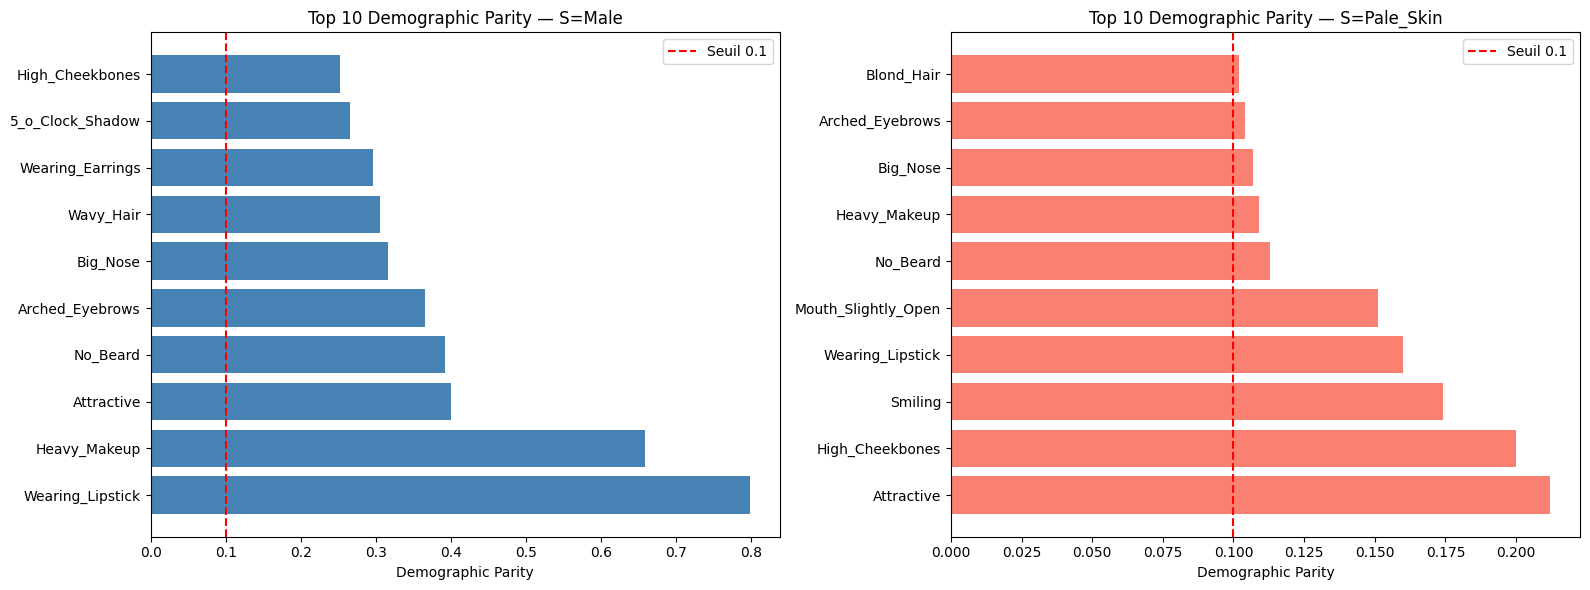

In [66]:
# Visualisation des top biais
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_male = results_male.nlargest(10, 'Demographic_Parity')
axes[0].barh(top_male['Attribute'], top_male['Demographic_Parity'], color='steelblue')
axes[0].set_title('Top 10 Demographic Parity — S=Male')
axes[0].set_xlabel('Demographic Parity')
axes[0].axvline(x=0.1, color='red', linestyle='--', label='Seuil 0.1')
axes[0].legend()

top_skin = results_skin.nlargest(10, 'Demographic_Parity')
axes[1].barh(top_skin['Attribute'], top_skin['Demographic_Parity'], color='salmon')
axes[1].set_title('Top 10 Demographic Parity — S=Pale_Skin')
axes[1].set_xlabel('Demographic Parity')
axes[1].axvline(x=0.1, color='red', linestyle='--', label='Seuil 0.1')
axes[1].legend()

plt.tight_layout()
plt.show()

S = Male
Il y a beaucoup de biais. Wearing_Lipstick et Heavy_Makeup sont quasi exclusivement féminins (DP > 0.65). Le plus problématique est Attractive (DI=0.41) : les femmes sont annotées attractives 2.4 fois plus souvent que les hommes, révélant un biais d'annotation genré fort.

S = Pale_Skin
Les biais sont plus modérés mais tout de même présents. Les personnes à peau pâle sont jugées attractives 42% plus souvent, ce qui traduit un biais ethnocentrique direct des annotateurs. Blond_Hair (DI=1.71) confirme la surreprésentation de traits européens.

En conclusion, un modèle entraîné à prédire Attractive sera structurellement biaisé à la fois par le genre et par la couleur de peau, même sans utiliser Male ou Pale_Skin directement.